<a href="https://colab.research.google.com/github/amy165/Insurance-Risk-Pricing-Analysis-End-to-End-Project/blob/main/notebooks/02_risk_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
full_df=pd.read_csv('cleaned_vehicle_insurance_new.csv')

In [4]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800996 entries, 0 to 800995
Data columns (total 24 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   SEX                800996 non-null  int64  
 1   INSR_BEGIN         800996 non-null  object 
 2   INSR_END           800996 non-null  object 
 3   INSR_TYPE          800996 non-null  int64  
 4   INSURED_VALUE      800996 non-null  float64
 5   PREMIUM            800996 non-null  float64
 6   OBJECT_ID          800996 non-null  int64  
 7   PROD_YEAR          800996 non-null  float64
 8   SEATS_NUM          800996 non-null  float64
 9   CARRYING_CAPACITY  800996 non-null  float64
 10  TYPE_VEHICLE       800996 non-null  object 
 11  CCM_TON            800996 non-null  float64
 12  MAKE               800996 non-null  object 
 13  USAGE              800996 non-null  object 
 14  CLAIM_PAID         800996 non-null  float64
 15  insured_redflag    800996 non-null  int64  
 16  PR

In [5]:
full_df['INSR_BEGIN'] = pd.to_datetime(full_df['INSR_BEGIN'])
full_df['INSR_END'] = pd.to_datetime(full_df['INSR_END'])

In [6]:
full_df.head()

,SEX,INSR_BEGIN,INSR_END,INSR_TYPE,INSURED_VALUE,PREMIUM,OBJECT_ID,PROD_YEAR,SEATS_NUM,CARRYING_CAPACITY,...,CLAIM_PAID,insured_redflag,PREMIUM_redflag,CARRYING_redflag,CCM_TON_redflag,SEATS_NUM_redflag,begin_year,policy_duration,has_claim,vehicle_age
0,0,2013-08-08,2014-08-07,1202,519755.22,7209.140,5000029885,2007.0,4.0,6.0,...,0.00,0,0,0,0,0,2013,364,0,6.0
1,0,2012-08-08,2013-08-07,1202,519755.22,7203.890,5000029885,2007.0,4.0,6.0,...,0.00,0,0,0,0,0,2012,364,0,5.0
2,0,2011-08-08,2012-08-07,1202,519755.22,7045.804,5000029885,2007.0,4.0,6.0,...,0.00,0,0,0,0,0,2011,365,0,4.0
3,0,2011-07-08,2011-08-07,1202,519755.22,287.250,5000029885,2007.0,4.0,6.0,...,0.00,0,0,0,0,0,2011,30,0,4.0
4,0,2013-08-08,2014-08-07,1202,285451.24,4286.900,5000029901,2010.0,4.0,7.0,...,19894.43,0,0,0,0,0,2013,364,1,3.0


In [7]:
analysis_df = full_df[full_df['PREMIUM'] > 0].copy()

In [8]:
zero_premium_df = full_df[full_df['PREMIUM'] == 0]

how much it cost free polices?

In [9]:
zero_premium_df['CLAIM_PAID'].sum()


np.float64(8250.0)

In [10]:
zero_premium_df['has_claim'].mean()

np.float64(0.04081632653061224)

analysis with premium>0

In [11]:
analysis_df.shape
analysis_df['PREMIUM'].min()

0.74

In [12]:
total_premium = analysis_df['PREMIUM'].sum()
total_claims = analysis_df['CLAIM_PAID'].sum()
loss_ratio_total = total_claims / total_premium

print("Total Premium:", round(total_premium,2))
print("Total Claims:", round(total_claims,2))
print("Loss Ratio:", round(loss_ratio_total,2))

Total Premium: 5936243551.2
Total Claims: 15412806568.82
Loss Ratio: 2.6


In [13]:
vehicle_analysis = analysis_df.groupby('TYPE_VEHICLE').agg({
    'PREMIUM': 'sum',
    'CLAIM_PAID': 'sum',
    'has_claim': 'mean'
})

vehicle_analysis['loss_ratio'] = vehicle_analysis['CLAIM_PAID'] / vehicle_analysis['PREMIUM']

vehicle_analysis.sort_values('loss_ratio', ascending=False)

,PREMIUM,CLAIM_PAID,has_claim,loss_ratio
TYPE_VEHICLE,,,,
Trailers and semitrailers,2.338357e+08,1.068030e+09,0.046220,4.567435
Truck,2.150554e+09,7.031165e+09,0.084800,3.269466
Bus,1.129539e+09,2.768532e+09,0.118500,2.451029
Pick-up,8.595036e+08,2.056175e+09,0.095421,2.392282
Tanker,1.796989e+08,4.223658e+08,0.055697,2.350408
Automobile,3.881369e+08,8.193636e+08,0.076165,2.111017
Station Wagones,6.940924e+08,1.032520e+09,0.117231,1.487583
Special construction,1.317003e+08,1.616732e+08,0.069137,1.227584
Motor-cycle,8.417835e+07,2.650089e+07,0.006533,0.314818


In [14]:
usage_analysis = analysis_df.groupby('USAGE').agg({
    'PREMIUM': 'sum',
    'CLAIM_PAID': 'sum',
    'has_claim': 'mean'
})

usage_analysis['loss_ratio'] = usage_analysis['CLAIM_PAID'] / usage_analysis['PREMIUM']

usage_analysis.sort_values('loss_ratio', ascending=False)

,PREMIUM,CLAIM_PAID,has_claim,loss_ratio
USAGE,,,,
General Cartage,1.911659e+09,7.602980e+09,0.089926,3.977164
Fare Paying Passengers,7.408301e+08,2.352447e+09,0.070686,3.175421
Own Goods,1.512398e+09,2.959236e+09,0.080038,1.956652
Learnes,9.315662e+06,1.807688e+07,0.034506,1.940482
Others,5.285032e+06,9.409605e+06,0.009375,1.780425
Ambulance,5.710758e+07,9.945651e+07,0.169388,1.741564
Private,1.026766e+09,1.758141e+09,0.077874,1.712310
Own service,4.427247e+08,4.991331e+08,0.088070,1.127412
Car Hires,2.171256e+07,2.321784e+07,0.052591,1.069328


In [15]:
pivot = analysis_df.pivot_table(
    values='CLAIM_PAID',
    index='TYPE_VEHICLE',
    columns='USAGE',
    aggfunc='sum'
) / analysis_df.pivot_table(
    values='PREMIUM',
    index='TYPE_VEHICLE',
    columns='USAGE',
    aggfunc='sum'
)

pivot

USAGE,Agricultural Any Farm,Agricultural Own Farm,Ambulance,Car Hires,Fare Paying Passengers,Fire fighting,General Cartage,Learnes,Others,Own Goods,Own service,Private,Special Construction,Taxi
TYPE_VEHICLE,,,,,,,,,,,,,,
Automobile,NaN,NaN,17.088563,1.115025,0.322286,0.000000,0.000000,0.135423,1.186866,0.846378,0.695175,2.145126,NaN,0.979001
Bus,NaN,NaN,1.738140,1.049023,3.289626,0.000000,1.841198,1.208380,2.855782,10.779227,1.017727,0.770666,NaN,0.935972
Motor-cycle,NaN,0.000000,NaN,1.044450,0.364447,0.000000,0.339908,0.017282,0.363524,0.188557,0.133546,0.378708,0.000000,0.214418
Pick-up,NaN,NaN,0.000000,1.167647,0.000000,0.000000,2.796433,0.000000,4.455013,2.386740,0.195382,2.292904,0.000000,0.000000
Special construction,0.000000,0.153409,1.990739,0.000000,0.000000,0.040150,0.038763,NaN,16.117582,0.187656,2.709955,0.000000,0.371230,0.000000
Station Wagones,NaN,NaN,1.569318,1.088576,0.000000,NaN,0.000000,0.000000,0.000000,0.488178,0.976434,1.507141,0.000000,0.000000
Tanker,NaN,NaN,NaN,NaN,NaN,NaN,3.944554,0.000000,0.000000,0.938868,0.000000,NaN,0.000000,NaN
Tractor,0.410549,0.266342,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000,0.066755,0.005445,0.000000,0.015375,NaN
Trade plates,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,NaN,NaN


In [16]:
freq = analysis_df.groupby('TYPE_VEHICLE')['has_claim'].mean()

severity = analysis_df[analysis_df['CLAIM_PAID'] > 0].groupby('TYPE_VEHICLE')['CLAIM_PAID'].mean()

risk_table = pd.concat([freq, severity], axis=1)
risk_table.columns = ['frequency', 'severity']

risk_table['risk'] = risk_table['frequency'] * risk_table['severity']

risk_table = risk_table.sort_values('risk', ascending=False)

risk_table

,frequency,severity,risk
TYPE_VEHICLE,,,
Truck,0.084800,549309.754353,46581.280844
Tanker,0.055697,713455.700152,39737.113039
Trailers and semitrailers,0.046220,644556.242523,29791.623260
Bus,0.118500,220617.774338,26143.140636
Station Wagones,0.117231,145016.892348,17000.416128
Pick-up,0.095421,148857.966170,14204.126077
Special construction,0.069137,193852.811918,13402.407787
Automobile,0.076165,85591.102729,6519.028280
Tractor,0.017641,131744.659652,2324.089573


In [17]:
premium_avg = analysis_df.groupby('TYPE_VEHICLE')['PREMIUM'].mean()

risk_table['avg_premium'] = premium_avg

risk_table['pricing_gap'] = risk_table['avg_premium'] - risk_table['risk']

risk_table.sort_values('pricing_gap')

,frequency,severity,risk,avg_premium,pricing_gap
TYPE_VEHICLE,,,,,
Truck,0.084800,549309.754353,46581.280844,14247.366100,-32333.914744
Trailers and semitrailers,0.046220,644556.242523,29791.623260,6522.614998,-23269.008261
Tanker,0.055697,713455.700152,39737.113039,16906.472173,-22830.640866
Bus,0.118500,220617.774338,26143.140636,10666.190761,-15476.949874
Pick-up,0.095421,148857.966170,14204.126077,5937.479617,-8266.646459
Station Wagones,0.117231,145016.892348,17000.416128,11428.211425,-5572.204703
Automobile,0.076165,85591.102729,6519.028280,3088.098407,-3430.929872
Special construction,0.069137,193852.811918,13402.407787,10917.707634,-2484.700153
Motor-cycle,0.006533,28373.539829,185.351991,588.758598,403.406608


Risk was estimated as the product of claim frequency and claim severity, representing the expected cost per policy.

<Axes: xlabel='TYPE_VEHICLE'>

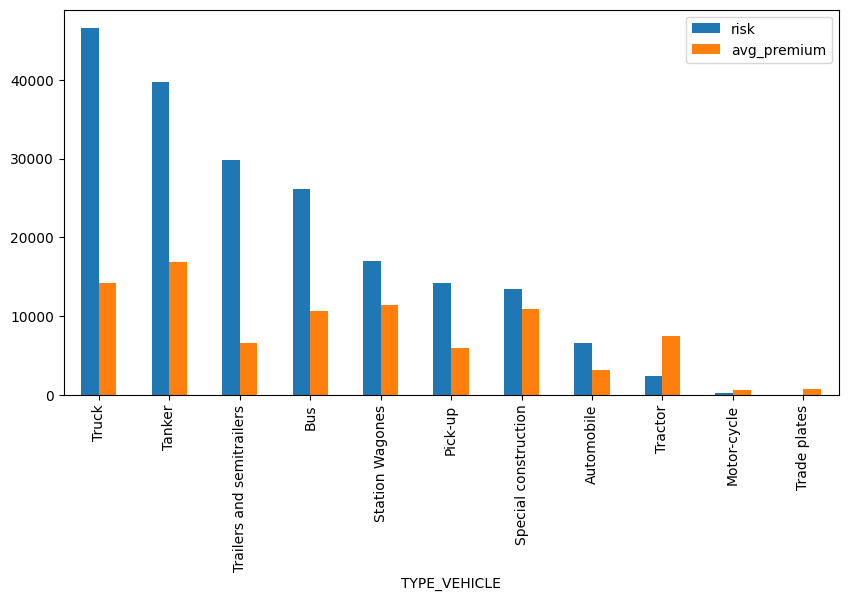

In [18]:
risk_table[['risk', 'avg_premium']].plot(kind='bar', figsize=(10,5))

In [19]:
analysis_df.groupby(['TYPE_VEHICLE','USAGE']).agg({
    'PREMIUM':'mean',
    'CLAIM_PAID':'mean',
    'has_claim':'mean'
}).head(50)

PREMIUM     CLAIM_PAID  \
TYPE_VEHICLE         USAGE                                                 
Automobile           Ambulance                7366.608000  125884.747333   
                     Car Hires                5263.289503    5868.701157   
                     Fare Paying Passengers   1633.070000     526.315789   
                     Fire fighting             698.235000       0.000000   
                     General Cartage          2666.781250       0.000000   
                     Learnes                   888.849000     120.370370   
                     Others                   2776.277494    3295.068148   
                     Own Goods                1732.056120    1465.973600   
                     Own service              3665.638200    2548.258875   
                     Private                  3292.807719    7063.489054   
                     Taxi                      843.139216     825.433980   
Bus                  Ambulance                9057.446404   15743.112609   
                     Car Hires                7770.058315    8150.970802   
                     Fare Paying Passengers  11785.228712   38768.993609   
                     Fire fighting            1629.200000       0.000000   
                     General Cartage          6247.512100   11502.905000   
                     Learnes                  4973.904532    6010.367113   
                     Others                  10842.010200   30962.413000   
                     Own Goods                1385.556672   14935.229508   
                     Own service             11995.228140   12207.869302   
                     Private                  3398.143844    2618.834063   
                     Taxi                     2119.005997    1983.331083   
Motor-cycle          Agricultural Own Farm     404.240000       0.000000   
                     Car Hires                 302.887088     316.350365   
                     Fare Paying Passengers    491.098309     178.979533   
                     Fire fighting             237.700000       0.000000   
                     General Cartage           480.168584     163.212993   
                     Learnes                   563.799705       9.743590   
                     Others                    465.059810     169.060196   
                     Own Goods                 671.801594     126.673147   
                     Own service               506.594613      67.653604   
                     Private                   750.262067     284.130282   
                     Special Construction      344.504167       0.000000   
                     Taxi                      698.242612     149.715677   
Pick-up              Ambulance                5786.680000       0.000000   
                     Car Hires                5979.679284    6982.157067   
                     Fare Paying Passengers   9580.093750       0.000000   
                     Fire fighting             688.250000       0.000000   
                     General Cartage          3653.149693   10215.787337   
                     Learnes                  1927.462500       0.000000   
                     Others                   1275.439636    5682.100000   
                     Own Goods                6024.776092   14379.572043   
                     Own service              4006.682462     782.835000   
                     Private                  2991.355821    6858.891071   
                     Special Construction      701.000000       0.000000   
                     Taxi                      639.250000       0.000000   
Special construction Agricultural Any Farm    8657.981892       0.000000   
                     Agricultural Own Farm    8891.061867    1363.967961   
                     Ambulance               15459.539402   30775.908575   
                     Car Hires               11320.238455       0.000000   

                                             has_claim  
TYPE_VEHICLE         USAGE              

In [20]:
value_df = analysis_df[analysis_df['INSURED_VALUE'] > 0].copy()

In [21]:
insured_zero_df = analysis_df[analysis_df['INSURED_VALUE'] == 0]

¿cuánto cuesta asegurar cosas sin valor declarado?

In [22]:
insured_zero_df['CLAIM_PAID'].sum()


np.float64(0.0)

In [23]:
insured_zero_df['has_claim'].mean()

nan

value-based risk analysis

In [24]:
value_df['insured_value_group'] = pd.cut(
    value_df['INSURED_VALUE'],
    bins=[0, 100000, 500000, 1000000, 250000000],
    labels=['low', 'medium', 'high', 'very_high'],
    include_lowest=True
)

value_analysis = value_df.groupby('insured_value_group', observed=False).agg({
    'has_claim': 'mean',
    'CLAIM_PAID': lambda x: x[x > 0].mean(),
    'PREMIUM': 'mean'
})

value_analysis['risk'] = value_analysis['has_claim'] * value_analysis['CLAIM_PAID']
value_analysis['gap'] = value_analysis['PREMIUM'] - value_analysis['risk']

value_analysis

,has_claim,CLAIM_PAID,PREMIUM,risk,gap
insured_value_group,,,,,
low,0.009011,47913.104519,597.667894,431.726750,165.941143
medium,0.078747,137553.907202,4180.836305,10832.022281,-6651.185976
high,0.082154,256781.790678,8006.519223,21095.547304,-13089.028081
very_high,0.116397,389589.672781,17222.336638,45347.084205,-28124.747567
